<a href="https://colab.research.google.com/github/EngMohamed-op/MBTI-Personality/blob/main/EDA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english') )
from wordcloud import WordCloud
import kagglehub
import matplotlib.ticker as mtick
!pip install vaderSentiment -q
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re
analyzer = SentimentIntensityAnalyzer()
!pip install textblob -q
from textblob import TextBlob

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:


# Download latest version
path = kagglehub.dataset_download("datasnaek/mbti-type")

print("Path to dataset files:", path)
df=pd.read_csv(path+"/mbti_1.csv")

100%|██████████| 24.4M/24.4M [00:01<00:00, 13.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/datasnaek/mbti-type/versions/1


In [33]:
df

,type,posts,clean_posts,Word_count,avg_word_lenght,lexical_diversity,self_reference_ratio,vader_compound,sentiment,IE,NS,TF,JP,punctuation_count,link_count
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,and moments sportscenter not top ten plays pra...,556,4.455036,0.607914,0.035971,0.9902,0.171752,I,N,F,J,5,24
1,ENTP,'I'm finding the lack of me in these posts ver...,im finding the lack of me in these posts very ...,1183,4.015216,0.428571,0.077768,0.9984,0.083652,E,N,T,P,4,10
2,INTP,'Good one _____ https://www.youtube.com/wat...,good one course to which i say i know thats my...,841,4.432818,0.513674,0.048751,0.9982,0.142715,I,N,T,P,13,5
3,INTJ,"'Dear INTP, I enjoyed our conversation the o...",dear i enjoyed our conversation the other day ...,1085,4.220276,0.438710,0.058986,0.9981,0.126660,I,N,T,J,12,2
4,ENTJ,'You're fired.|||That's another silly misconce...,youre fired thats another silly misconception ...,997,4.353059,0.463390,0.043129,0.9848,0.069332,E,N,T,J,9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8670,ISFP,'https://www.youtube.com/watch?v=t8edHB_h908||...,just because i always think of cats as fi doms...,826,4.318402,0.475787,0.048426,0.9940,0.128769,I,S,F,P,11,7
8671,ENFP,'So...if this thread already exists someplace ...,soif this thread already exists someplace else...,1340,4.252239,0.392537,0.081343,0.9998,0.194343,E,N,F,P,43,3
8672,INTP,'So many questions when i do these things. I ...,so many questions when i do these things i wou...,966,4.318841,0.487578,0.037267,0.9976,0.142632,I,N,T,P,8,2
8673,INFP,'I am very conflicted right now when it comes ...,i am very conflicted right now when it comes t...,1724,4.091067,0.346868,0.082947,0.9996,0.106141,I,N,F,P,12,0


In [3]:
df.isnull().sum()

,0
type,0
posts,0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8675 entries, 0 to 8674
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    8675 non-null   object
 1   posts   8675 non-null   object
dtypes: object(2)
memory usage: 135.7+ KB


In [6]:
df.describe(include='object')

,type,posts
count,8675,8675
unique,16,8675
top,INFP,'It has been too long since I have been on per...
freq,1832,1


In [7]:
# Clean posts before any analysis
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'\|\|\|', ' ', text)               # replace ||| with space
    mbti_types = ['infj','entp','intp','intj','entj','infp','enfp','istp',
                  'isfp','estj','istj','enfj','isfj','esfj','esfp','estp']
    for t in mbti_types:
        text = re.sub(r'\b' + t + r'\b', '', text)   # remove MBTI mentions
    text = re.sub(r'[^a-z\s!?]', '', text)            # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_posts'] = df['posts'].apply(clean_text)
print('✅ Cleaning done!')


✅ Cleaning done!


In [13]:
# Use clean_posts instead of raw posts

df['Word_count'] = df['clean_posts'].apply(lambda x: len(x.split()))
df['avg_word_lenght'] = df['clean_posts'].apply(lambda x: np.mean(list(map(len, x.split()))))
df['lexical_diversity'] = df['clean_posts'].apply(lambda x: len(set(x.split())) / len(x.split()))

self_words = ['i', 'me', 'my', 'myself']
df['self_reference_ratio'] = df['clean_posts'].apply(
    lambda x: sum(word in self_words for word in x.split()) / len(x.split()))

# TextBlob instead of VADER
df['sentiment'] = df['clean_posts'].apply(lambda x: TextBlob(x).sentiment.polarity)

df['IE'] = df['type'].apply(lambda x: x[0])
df['NS'] = df['type'].apply(lambda x: x[1])
df['TF'] = df['type'].apply(lambda x: x[2])
df['JP'] = df['type'].apply(lambda x: x[3])

df['punctuation_count'] = df['clean_posts'].apply(lambda x: x.count('!') + x.count('?'))
df['link_count'] = df['posts'].apply(lambda x: x.count('http') + x.count('#'))

df.head()

,type,posts,clean_posts,Word_count,avg_word_lenght,lexical_diversity,self_reference_ratio,vader_compound,sentiment,IE,NS,TF,JP,punctuation_count,link_count
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,and moments sportscenter not top ten plays pra...,556,4.455036,0.607914,0.035971,0.9902,0.171752,I,N,F,J,5,24
1,ENTP,'I'm finding the lack of me in these posts ver...,im finding the lack of me in these posts very ...,1183,4.015216,0.428571,0.077768,0.9984,0.083652,E,N,T,P,4,10
2,INTP,'Good one _____ https://www.youtube.com/wat...,good one course to which i say i know thats my...,841,4.432818,0.513674,0.048751,0.9982,0.142715,I,N,T,P,13,5
3,INTJ,"'Dear INTP, I enjoyed our conversation the o...",dear i enjoyed our conversation the other day ...,1085,4.220276,0.438710,0.058986,0.9981,0.126660,I,N,T,J,12,2
4,ENTJ,'You're fired.|||That's another silly misconce...,youre fired thats another silly misconception ...,997,4.353059,0.463390,0.043129,0.9848,0.069332,E,N,T,J,9,6


/tmp/ipykernel_355/3152398490.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='coolwarm', ax=axes[1])


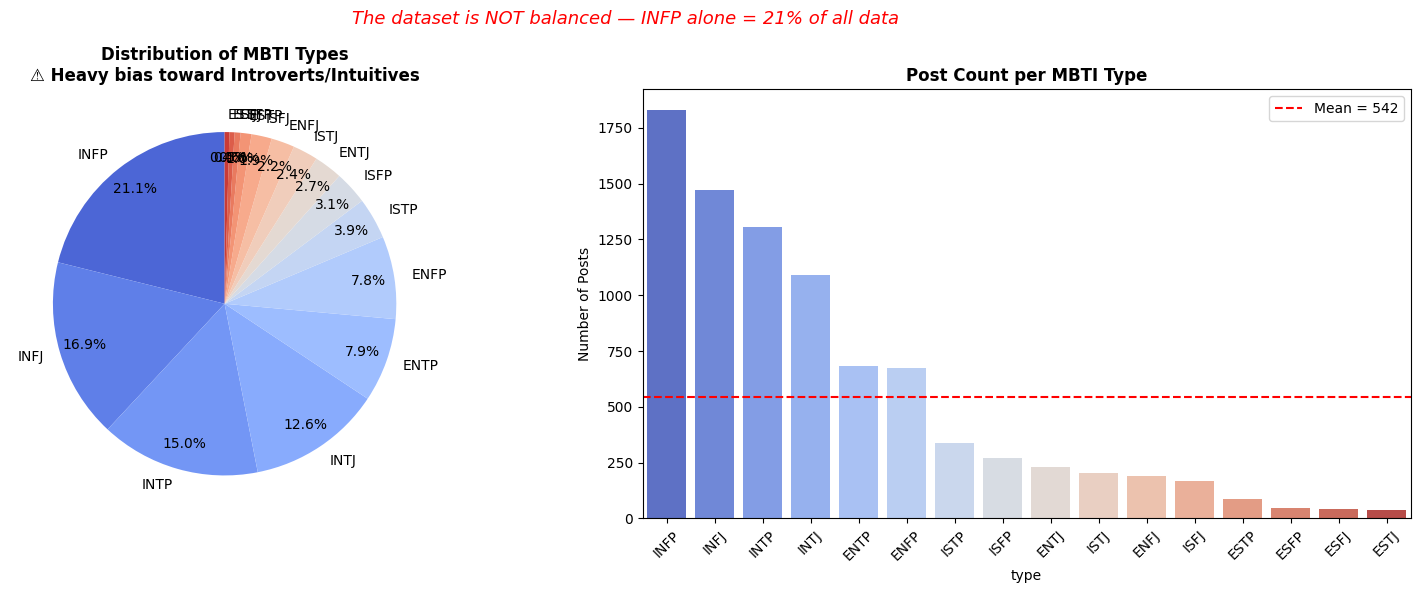

In [35]:
# Q1: Is the data balanced? Imbalanced data = biased conclusions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
counts = df['type'].value_counts()
colors = sns.color_palette('coolwarm', 16)

axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, pctdistance=0.85)
axes[0].set_title('Distribution of MBTI Types\n⚠️ Heavy bias toward Introverts/Intuitives',
                  fontweight='bold')

sns.barplot(x=counts.index, y=counts.values, palette='coolwarm', ax=axes[1])
axes[1].axhline(counts.mean(), color='red', linestyle='--',
                label=f'Mean = {counts.mean():.0f}')
axes[1].set_title('Post Count per MBTI Type', fontweight='bold')
axes[1].set_ylabel('Number of Posts')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.suptitle('The dataset is NOT balanced — INFP alone = 21% of all data',
             fontsize=13, color='red', fontstyle='italic')
plt.tight_layout()
plt.show()




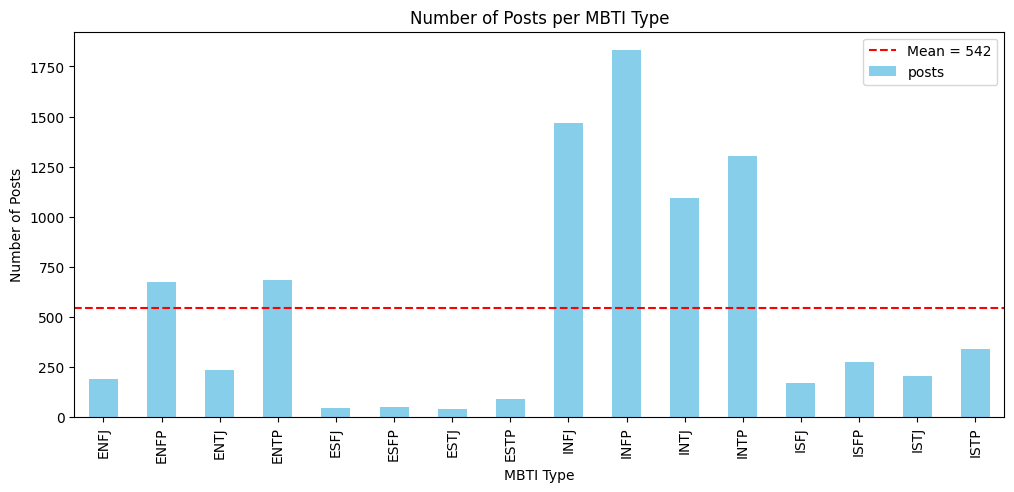

In [17]:
# Q2: Does post count differ across types — and does that affect our analysis?
post_counts = df.groupby('type')['posts'].count()
post_counts.plot(kind='bar', figsize=(12,5), color='skyblue')
plt.axhline(post_counts.mean(), color='red', linestyle='--', label=f'Mean = {post_counts.mean():.0f}')
plt.title("Number of Posts per MBTI Type")
plt.ylabel("Number of Posts")
plt.xlabel("MBTI Type")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


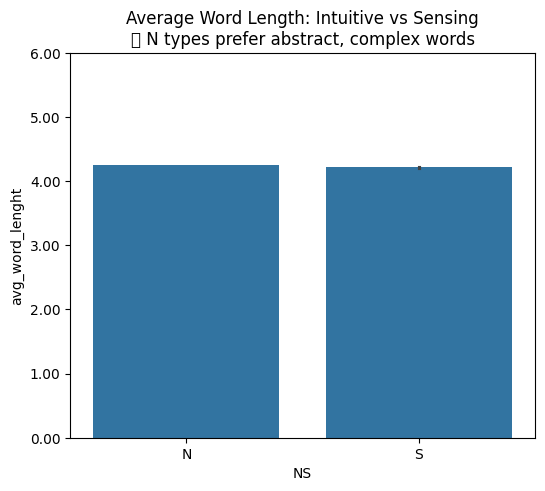

In [18]:
# Q3: Do Intuitive types use more complex vocabulary than Sensing types?
#what is intuitive and what is sensing
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='NS', y='avg_word_lenght')
plt.title("Average Word Length: Intuitive vs Sensing\n💡 N types prefer abstract, complex words")
plt.ylim(0,6)
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


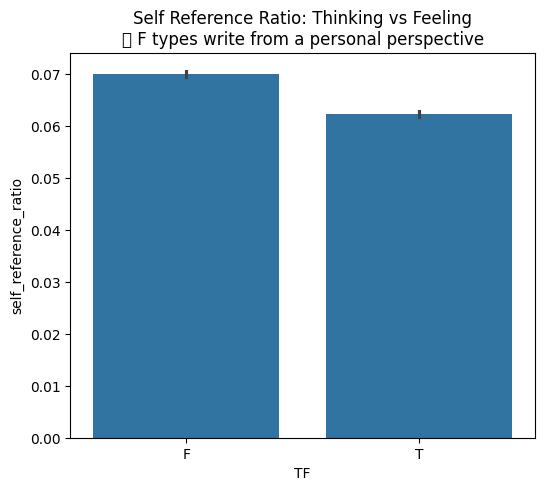

In [19]:
# Q4: Do Feeling types talk about themselves more than Thinking types?
#feelings and thinking?
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='TF', y='self_reference_ratio')
plt.title("Self Reference Ratio: Thinking vs Feeling\n💡 F types write from a personal perspective")
plt.show()

/tmp/ipykernel_355/4101233007.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='type', y='Word_count', data=avg_word_count, palette='Blues_d')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


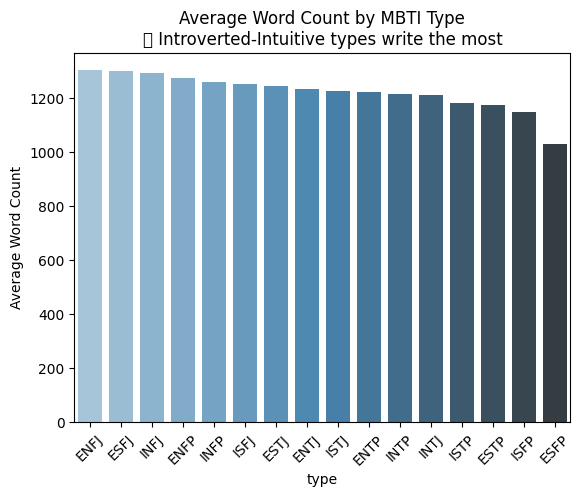

In [20]:
# Q6: Do certain MBTI types write longer posts on average?
avg_word_count = df.groupby('type')['Word_count'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='type', y='Word_count', data=avg_word_count, palette='Blues_d')
plt.title("Average Word Count by MBTI Type\n💡 Introverted-Intuitive types write the most")
plt.ylabel("Average Word Count")
plt.xticks(rotation=45)
plt.show()

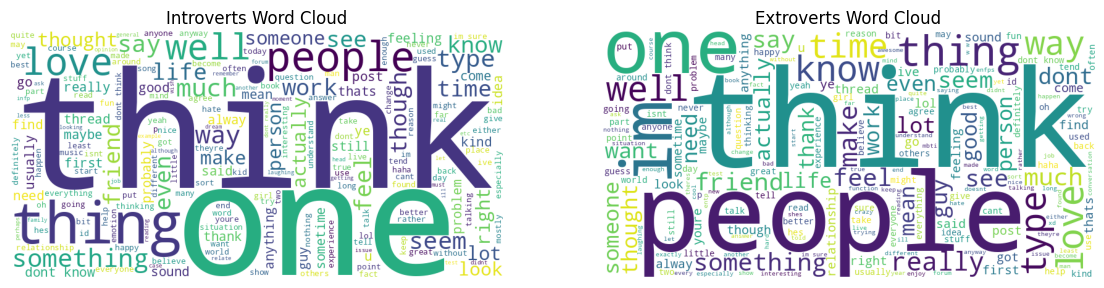

In [22]:
# Q5: What words define Introverts vs Extroverts?
intro_text = " ".join(df[df['IE'] == 'I']['clean_posts']).split()
intro_words = [w for w in intro_text if w not in stop_words]
extro_text = " ".join(df[df['IE'] == 'E']['clean_posts']).split()
extro_words = [w for w in extro_text if w not in stop_words]

wc_intro = WordCloud(width=800, height=400, background_color='white').generate(" ".join(intro_words))
wc_extro = WordCloud(width=800, height=400, background_color='white').generate(" ".join(extro_words))

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(wc_intro)
plt.axis("off")
plt.title("Introverts Word Cloud")
plt.subplot(1,2,2)
plt.imshow(wc_extro)
plt.axis("off")
plt.title("Extroverts Word Cloud")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


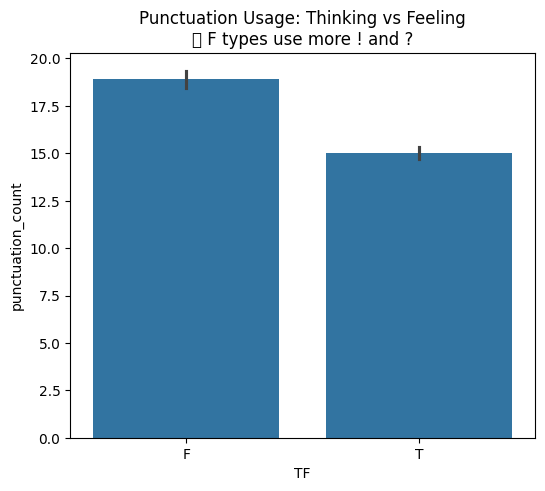

In [21]:
# Q7: Does punctuation usage reveal emotional expressiveness?
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='TF', y='punctuation_count')
plt.title("Punctuation Usage: Thinking vs Feeling\n💡 F types use more ! and ?")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


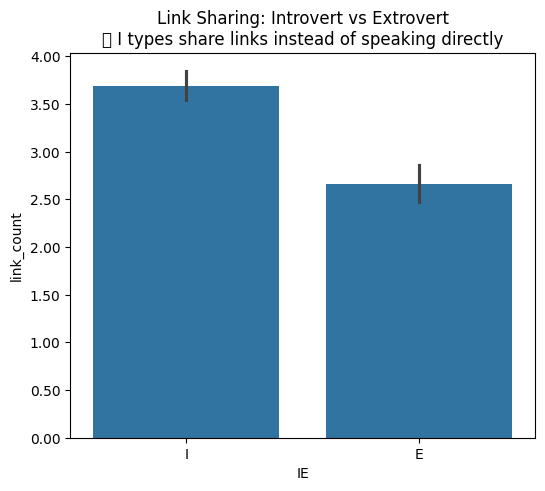

In [23]:
# Q8: Do Introverts share more links than Extroverts?
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='IE', y='link_count')
plt.title("Link Sharing: Introvert vs Extrovert\n💡 I types share links instead of speaking directly")
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.show()

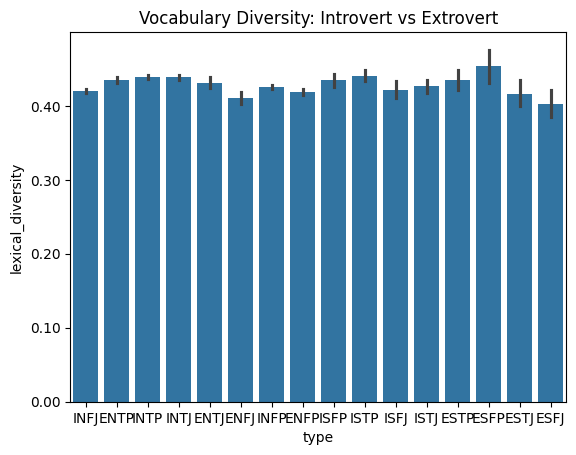

In [34]:
# Q9: Do certain types write with more vocabulary diversity?
sns.barplot(data=df, x='type', y='lexical_diversity')
plt.title("Vocabulary Diversity: Introvert vs Extrovert")
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.show()

/tmp/ipykernel_355/863346221.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='TF', y='sentiment', palette='Set1', ax=axes[1])
/tmp/ipykernel_355/863346221.py:13: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


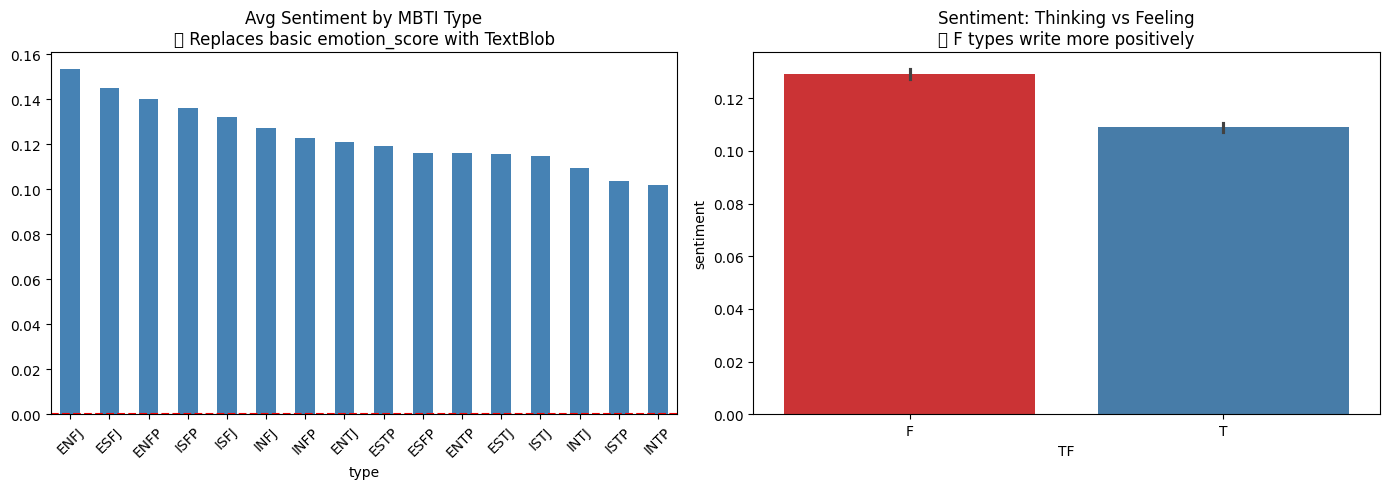

In [25]:
# Q10: Which MBTI types write most positively or negatively?
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sentiment_avg = df.groupby('type')['sentiment'].mean().sort_values(ascending=False)
sentiment_avg.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("Avg Sentiment by MBTI Type\n💡 Replaces basic emotion_score with TextBlob")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='TF', y='sentiment', palette='Set1', ax=axes[1])
axes[1].set_title("Sentiment: Thinking vs Feeling\n💡 F types write more positively")

plt.tight_layout()
plt.show()

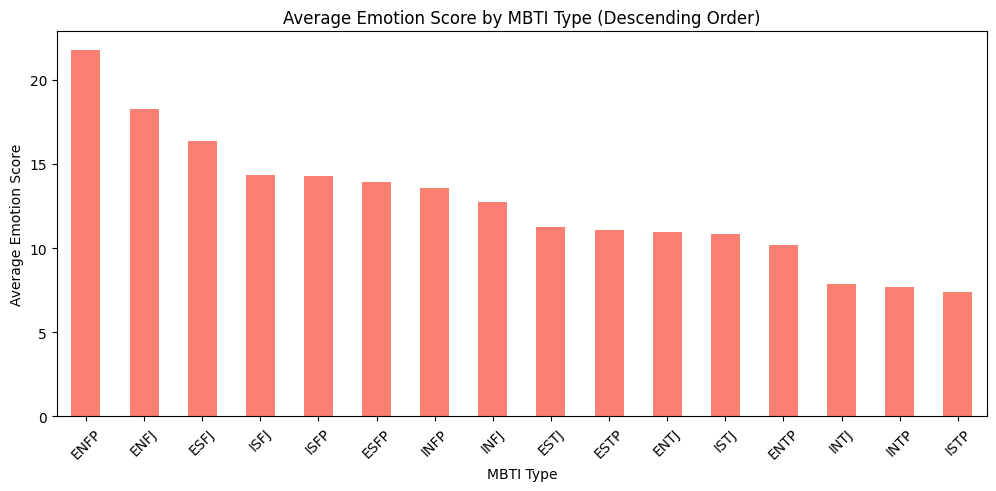

In [ ]:

emotion_avg = df.groupby('type')['emotion_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
emotion_avg.plot(kind='bar', color='salmon')
plt.title("Average Emotion Score by MBTI Type (Descending Order)")
plt.ylabel("Average Emotion Score")
plt.xlabel("MBTI Type")
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


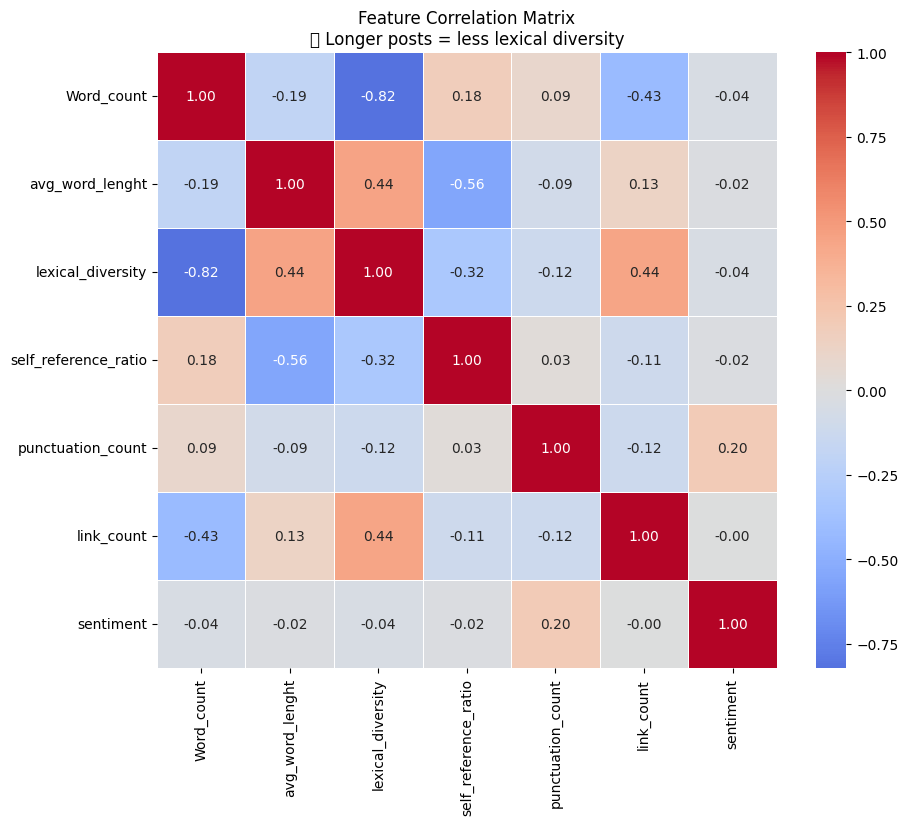

In [36]:
# Q11: Which features are correlated with each other?
plt.figure(figsize=(10,8))
sns.heatmap(df[['Word_count','avg_word_lenght','lexical_diversity','self_reference_ratio',
                'punctuation_count','link_count','sentiment']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Feature Correlation Matrix\n💡 Longer posts = less lexical diversity")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


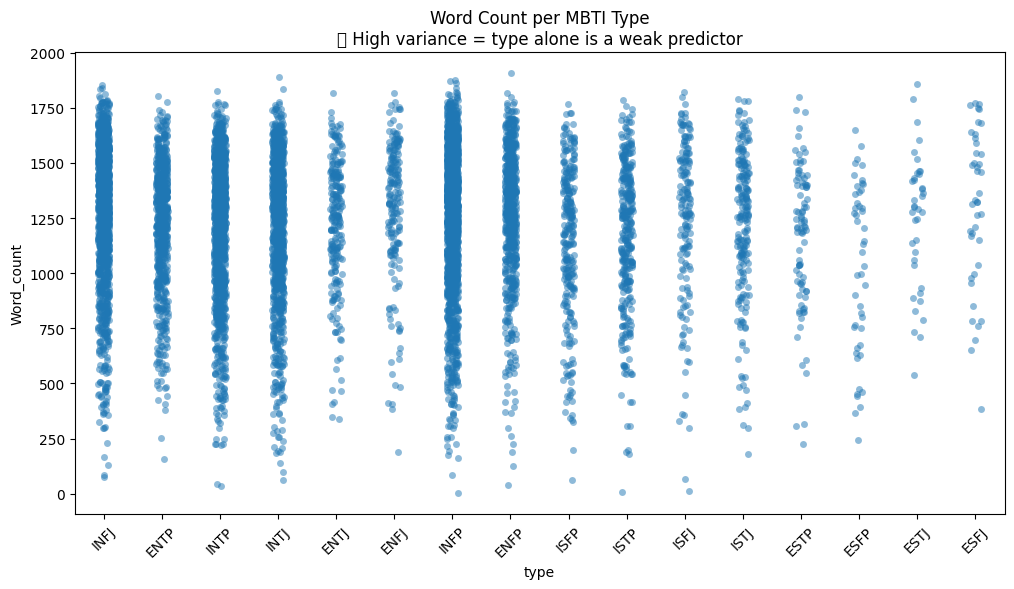

In [27]:
# Q12: Is there high variance in writing length within each type?
plt.figure(figsize=(12,6))
sns.stripplot(data=df, x='type', y='Word_count', jitter=True, alpha=0.5)
plt.xticks(rotation=45)
plt.title("Word Count per MBTI Type\n💡 High variance = type alone is a weak predictor")
plt.show()

/tmp/ipykernel_355/1631959299.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='JP', y='punctuation_count', palette=['lightblue','salmon'])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


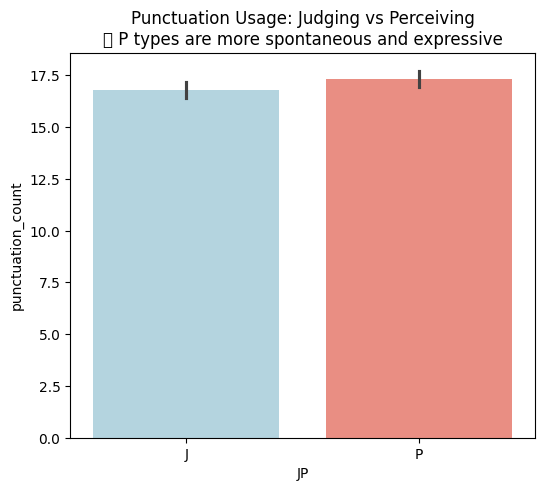

In [37]:
# Q15: Do Judging types use more punctuation than Perceiving types?
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='JP', y='punctuation_count', palette=['lightblue','salmon'])
plt.title("Punctuation Usage: Judging vs Perceiving\n💡 P types are more spontaneous and expressive")
plt.show()

/tmp/ipykernel_355/3211663344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='TF', y='link_count', palette='Set2')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


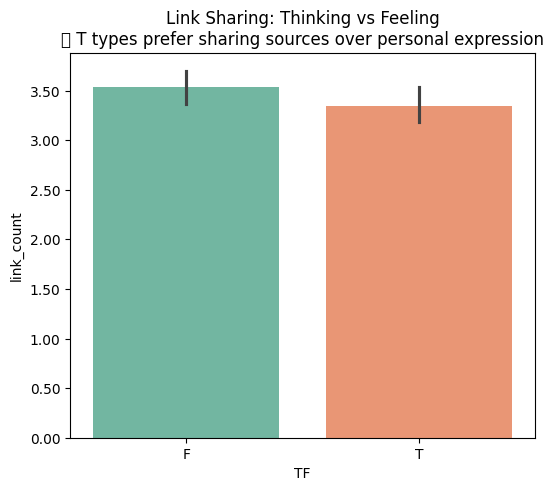

In [30]:
# Q16: Do Thinking types share more links than Feeling types?
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='TF', y='link_count', palette='Set2')
plt.title("Link Sharing: Thinking vs Feeling\n💡 T types prefer sharing sources over personal expression")
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.show()

/tmp/ipykernel_355/3429040527.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='JP', y='Word_count', palette='Set2', ax=axes[0])
/tmp/ipykernel_355/3429040527.py:14: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


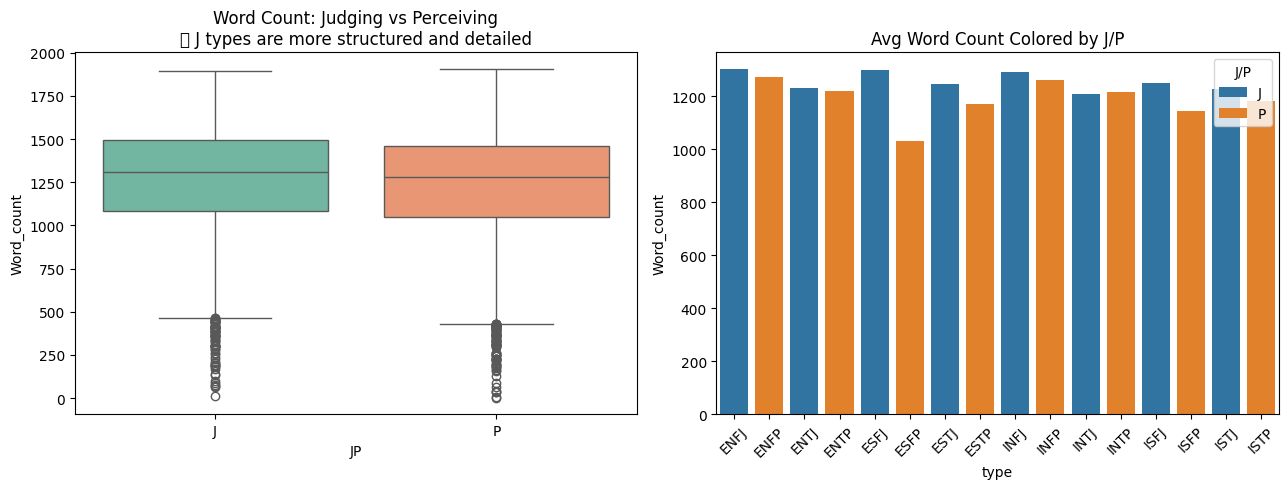

In [32]:
# Q18: Do Judging types write longer posts than Perceiving types?
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.boxplot(data=df, x='JP', y='Word_count', palette='Set2', ax=axes[0])
axes[0].set_title("Word Count: Judging vs Perceiving\n💡 J types are more structured and detailed")

avg_jp = df.groupby('type')['Word_count'].mean().reset_index()
avg_jp['JP'] = avg_jp['type'].apply(lambda x: x[3])
sns.barplot(data=avg_jp, x='type', y='Word_count', hue='JP', ax=axes[1], dodge=False)
axes[1].set_title("Avg Word Count Colored by J/P")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='J/P')

plt.tight_layout()
plt.show()